# Análise CPGF - 2024 | Transparência nos Gastos do Governo Federal

## Objetivo:
Analisar padrões de gastos com Cartões Corporativos (CPGF) do Governo Federal em 2024, 
identificando órgãos, categorias e períodos de maior despesa.

## Dataset:
- **Fonte:** Portal da Transparência
- **Período:** Janeiro 2024 a Dezembro 2024
- **Total de Registros:** 141.048
- **Colunas:** 15

## Visualizações:
1. Top 10 órgãos por gasto total
2. Distribuição por tipo de transação (com análise de sigilo)
3. Sazonalidade mensal dos gastos
4. Top 10 portadores
5. Top 10 favorecidos
6. Ticket médio por órgão

## - Setups & Importações

In [ ]:
# Importações das Bibliotecas utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import warnings

# Configurar avisos
warnings.filterwarnings('ignore')

# Configurações de visualização do Matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

plt.rcParams.update({
    'figure.figsize':        (14, 6),
    'figure.dpi':            150,
    'font.family':           'DejaVu Sans',
    'font.size':             11,
    'axes.titlesize':        14,
    'axes.titleweight':      'bold',
    'axes.labelsize':        11,
    'xtick.labelsize':       9,
    'ytick.labelsize':       9,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'figure.facecolor':      'white',
    'axes.facecolor':        '#F8F9FA',
    'savefig.dpi':           150,
    'savefig.bbox':          'tight',
})

## - Carregamento de Dados

In [ ]:
conn = sqlite3.connect(r'C:\Users\User\Desktop\Projeto_GOV_DATA\Database_CPGF\cpgf_2024.db')
df = pd.read_sql_query("SELECT * FROM cpgf", conn)
conn.close()

print(f"Registros: {len(df):,}")
print(f"Colunas: {len(df.columns)}")


Registros: 141,048
Colunas: 15


## - Exploração inicial dos Dados:

In [3]:
# Analise das primeiras linhas da estrutura dos dados
print("ANALISE INICIAL:")
df.head()

ANALISE INICIAL:


,codigo_orgao_superior,nome_orgao_superior,codigo_orgao,nome_orgao,codigo_unidade_gestora,nome_unidade_gestora,ano_extrato,mes_extrato,cpf_portador,nome_portador,cnpj_cpf_favorecido,nome_favorecido,transacao,data_transacao,valor_transacao
0,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2024,1,***.866.951-**,JONAS SCHOTTZ DA SILVA,37828985000158,CASA DO SINDICO LTDA,COMPRA A/V - R$ - APRES,30/11/2023,144.0
1,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2024,1,***.195.852-**,JOSE UELISSON ALVES LEITE,04932603000182,C. & C. COMERCIO DE INFORMATICA LTDA,COMPRA A/V - R$ - APRES,30/11/2023,8.0
2,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2024,1,***.562.861-**,ANTONIO CARLOS MELO DOS SANTOS,05136706000107,LEO ARTE - IMPRESSOES GRAFICAS LTDA,COMPRA A/V - R$ - APRES,01/12/2023,720.0
3,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2024,1,***.866.951-**,JONAS SCHOTTZ DA SILVA,05471879000173,KASA MOTORS LTDA,COMPRA A/V - R$ - APRES,29/11/2023,135.0
4,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2024,1,***.195.852-**,JOSE UELISSON ALVES LEITE,19878460000145,AUTO POSTO LIBERDADE LTDA,COMPRA A/V - R$ - APRES,29/11/2023,1290.0


In [4]:
# Analise de tipos de dados
print("\nINFORMAÇÕES DO DATAFRAME:")
df.info()


INFORMAÇÕES DO DATAFRAME:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141048 entries, 0 to 141047
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   codigo_orgao_superior   141048 non-null  object 
 1   nome_orgao_superior     141048 non-null  object 
 2   codigo_orgao            141048 non-null  object 
 3   nome_orgao              141048 non-null  object 
 4   codigo_unidade_gestora  141048 non-null  object 
 5   nome_unidade_gestora    141048 non-null  object 
 6   ano_extrato             141048 non-null  int64  
 7   mes_extrato             141048 non-null  int64  
 8   cpf_portador            104576 non-null  object 
 9   nome_portador           141048 non-null  object 
 10  cnpj_cpf_favorecido     141048 non-null  object 
 11  nome_favorecido         141048 non-null  object 
 12  transacao               141048 non-null  object 
 13  data_transacao          104576 non-null  object

In [35]:
# Calcular estatísticas descritivas
print("\nESTATISTICAS DESCRITIVAS:")
df.describe()


ESTATISTICAS DESCRITIVAS:


,ano_extrato,mes_extrato,valor_transacao
count,141048.0,141048.000000,141048.000000
mean,2024.0,7.283074,712.444261
std,0.0,3.286975,2199.291050
min,2024.0,1.000000,0.040000
25%,2024.0,5.000000,139.915000
50%,2024.0,7.000000,398.000000
75%,2024.0,10.000000,1000.000000
max,2024.0,12.000000,207953.600000


## - Limpeza de Dados:

In [6]:
print("=" * 35)
print("VERIFICAÇÃO DE LIMPEZA DE DADOS!")
print("=" * 35)

print(f"\nVALORES AUSENTES:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("Nenhum valor ausente!")

print(f"\nDUPLICATAS")
duplicatas = df.duplicated().sum()
print(f"Total de {duplicatas} linhas duplicadas")

VERIFICAÇÃO DE LIMPEZA DE DADOS!

VALORES AUSENTES:
cpf_portador      36472
data_transacao    36472
dtype: int64

DUPLICATAS
Total de 32121 linhas duplicadas


In [ ]:
# Investigando as duplicatas
cols_relevantes = ['cpf_portador', 'nome_favorecido', 'valor_transacao', 'data_transacao']
duplicatas_reais = df.duplicated(subset=cols_relevantes).sum()

print(f"Duplicatas (critério amplo - 15 colunas): {32121:,}")
print(f"Duplicatas (critério relevante - 4 colunas): {duplicatas_reais:,}")

# Exemplo de duplicata para análise visual
print("\nEXEMPLO DE LINHAS DUPLICADAS:")
mask = df.duplicated(subset=cols_relevantes, keep=False)
print(df[mask][cols_relevantes + ['nome_portador']].head(6))

Duplicatas (critério amplo - 15 colunas):     32,121
Duplicatas (critério relevante - 4 colunas):  34,439

EXEMPLO DE LINHAS DUPLICADAS:
       cpf_portador                        nome_favorecido  valor_transacao  \
14   ***.287.461-**                          NAO SE APLICA           1000.0   
15   ***.287.461-**                          NAO SE APLICA           1000.0   
58   ***.139.961-**  PAGAR.ME INSTITUICAO DE PAGAMENTO S.A             29.0   
59   ***.139.961-**  PAGAR.ME INSTITUICAO DE PAGAMENTO S.A             29.0   
382  ***.789.309-**  PAGAR.ME INSTITUICAO DE PAGAMENTO S.A           1110.0   
383  ***.789.309-**  PAGAR.ME INSTITUICAO DE PAGAMENTO S.A           1110.0   

    data_transacao             nome_portador  
14      18/12/2023  MARCELO MATTA DOS SANTOS  
15      18/12/2023  MARCELO MATTA DOS SANTOS  
58      07/12/2023    FILIPE SANTOS OLIVEIRA  
59      07/12/2023    FILIPE SANTOS OLIVEIRA  
382     12/12/2023  CELSO FERNANDES HONORATO  
383     12/12/2023  CELSO F

In [8]:
print(df[df.duplicated()].head(10))

     codigo_orgao_superior                           nome_orgao_superior  \
15                   63000                      Advocacia-Geral da União   
59                   25201  Banco Central do Brasil - Orçamento Fiscal e   
383                  22000          Ministério da Agricultura e Pecuária   
1153                 52000                          Ministério da Defesa   
1161                 52000                          Ministério da Defesa   
1164                 52000                          Ministério da Defesa   
1710                 52000                          Ministério da Defesa   
1711                 52000                          Ministério da Defesa   
1729                 52000                          Ministério da Defesa   
1734                 52000                          Ministério da Defesa   

     codigo_orgao                                         nome_orgao  \
15          63000  Advocacia-Geral da União - Unidades com víncul...   
59          25201  

In [9]:
"""
NOTA SOBRE INTEGRIDADE DOS DADOS:

Justificativa:
- As linhas identificadas como duplicatas podem representar 
  transações legítimas realizadas pelo mesmo portador, no mesmo 
  estabelecimento e valor, em datas próximas.
- Como não temos um ID único de transação para confirmar uma 
  duplicidade real, a remoção poderia eliminar dados válidos!!
- A análise foca em padrões agregados de gastos por órgão, 
  favorecido e período e não em transações individuais.
- Total mantido: 141.048 registros
"""
print("Dataset mantido íntegro sem remoções de dados")

Dataset mantido íntegro sem remoções de dados


## - Visualizações dos Dados

#### 1 - Distribuição de Gastos por Órgão/Ministério

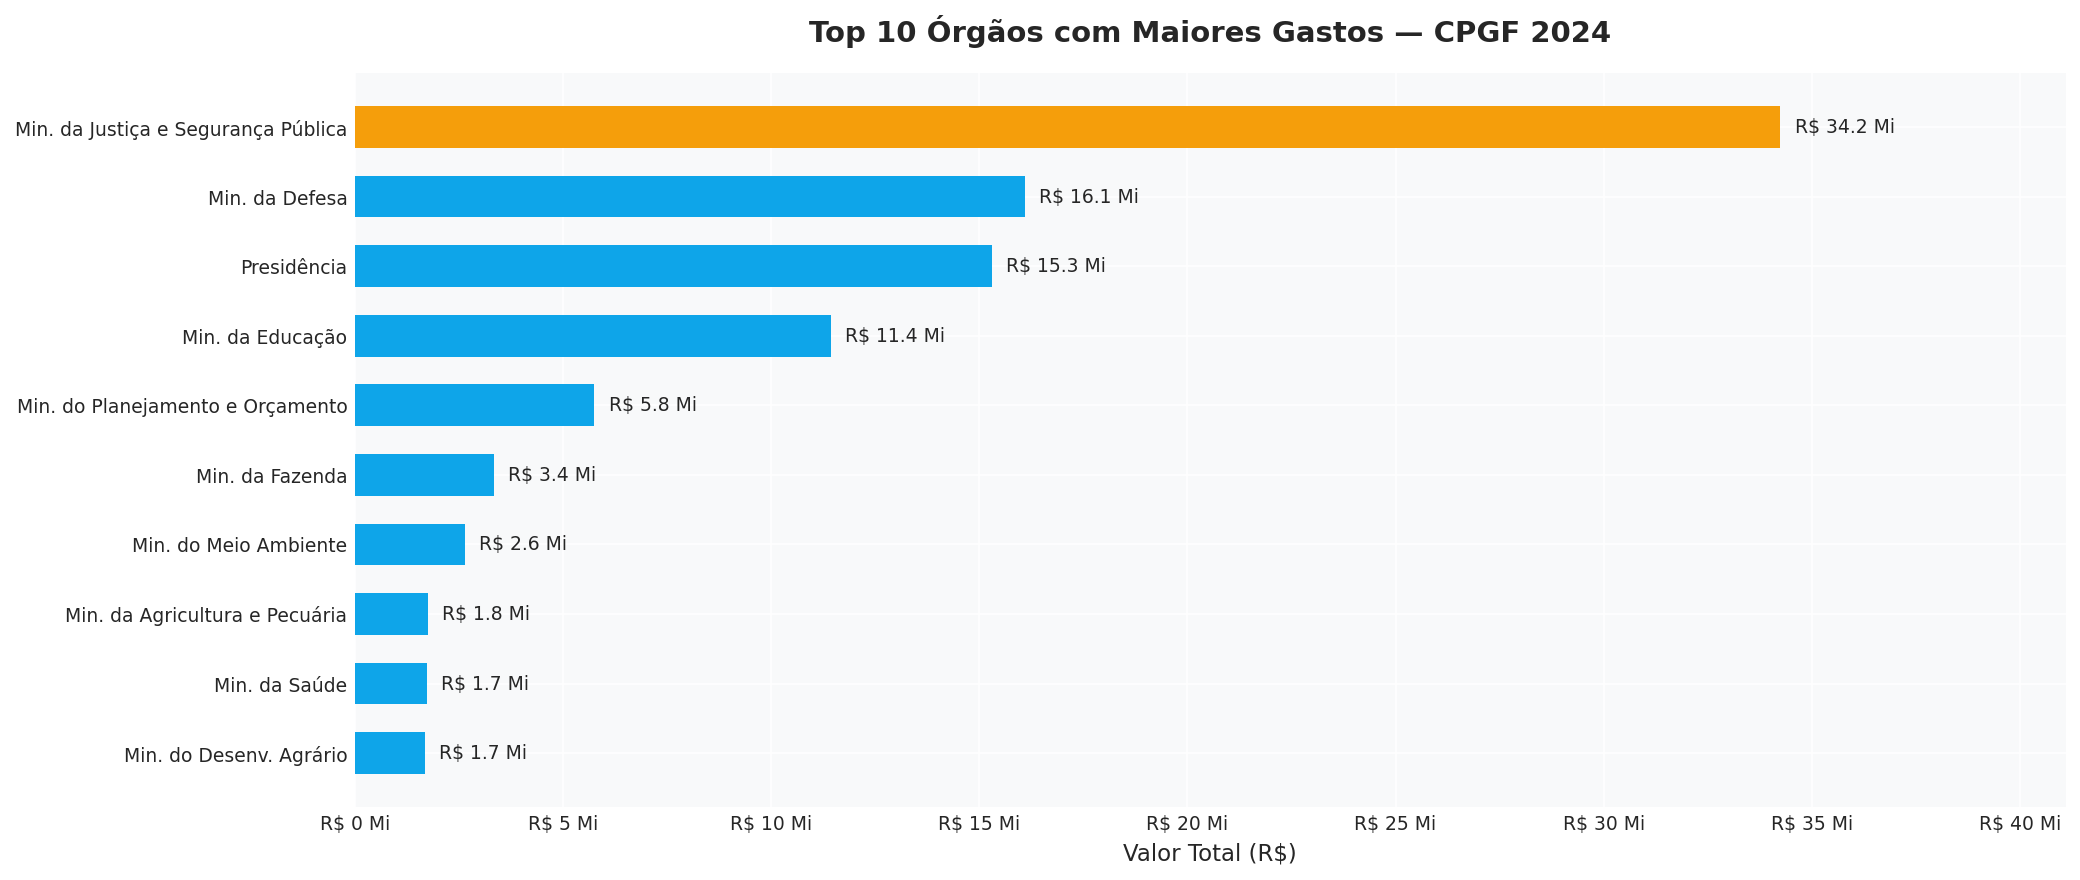

In [10]:
"""
Análise dos Top 10 Órgãos/Ministérios com maiores gastos em CPGF 2024.

Processo:
1. Agrupa gastos por órgão superior e soma os valores
2. Seleciona os top 10 em ordem crescente (menor para maior)
3. Simplifica nomes longos para melhor visualização
4. Corrige nomes truncados pelo Portal da Transparência
5. Destaca o maior gasto com cor destacada

Simplificações aplicadas:
- "Ministério" para "Min."
- Remove sufixos como "da República", "do Brasil", "Federal"
- Nomes truncados pelo banco corrigidos manualmente

Resultado: Gráfico de barras horizontal mostrando quais são os órgãos
que mais gastaram com cartões corporativos em 2024.
"""

# Agrupa e seleciona top 10
gastos_orgao = (df.groupby('nome_orgao_superior')['valor_transacao'].sum().nlargest(10).sort_values(ascending=True))

# Simplifica nomes longos
gastos_orgao.index = (gastos_orgao.index
                      .str.replace('Ministério', 'Min.')
                      .str.replace(' da República', '')
                      .str.replace(' do Brasil', '')
                      .str.replace(' Federal', '')
                      .str.replace('e Mudança do Clima', '')
                      .str.replace('Agrário e Agricultura Familiar', '')
                      .str.replace('Agrário e Agricultura', '')
                      .str.replace('Min. do Meio Ambiente e Mudança do Cl', 'Min. do Meio Ambiente')
                      .str.replace('Min. do Desenvolvimento Agrário e Agr', 'Min. do Desenv. Agrário')
                      .str.split('-').str[0]
                      .str.strip())

# Cores — destaca o maior, gradiente nos demais
n = len(gastos_orgao)
cores = ['#0EA5E9'] * n
cores[-1] = '#F59E0B'  # último = maior valor = destaque amarelo

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(gastos_orgao.index, gastos_orgao.values, color=cores, height=0.6)

# Rótulos de valor
for bar, val in zip(bars, gastos_orgao.values):
    ax.text(val + gastos_orgao.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'R$ {val/1e6:.1f} Mi',
            va='center', ha='left', fontsize=9)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.0f} Mi'))

ax.set_xlim(0, gastos_orgao.max() * 1.2)
ax.set_title('Top 10 Órgãos com Maiores Gastos — CPGF 2024', pad=15)
ax.set_xlabel('Valor Total (R$)')

plt.tight_layout()
plt.savefig('grafico_1_orgaos.png')
plt.show()

In [32]:
# ANÁLISE DO GRÁFICO 
gastos_orgao_analise = (df.groupby('nome_orgao_superior')['valor_transacao'].sum().nlargest(10).sort_values(ascending=False))

total_geral = df['valor_transacao'].sum()
maior_orgao = gastos_orgao_analise.index[0]
maior_valor = gastos_orgao_analise.iloc[0]
segundo_valor = gastos_orgao_analise.iloc[1]
proporcao = maior_valor / segundo_valor
top3 = gastos_orgao_analise.iloc[:3].sum()
pct_top3 = (top3 / total_geral) * 100

print("=" * 60)
print("TOP 10 ÓRGÃOS COM MAIORES GASTOS CPGF 2024")
print("=" * 60)

print("\nRANKING DOS TOP 10 ÓRGÃOS:")
for i, (orgao, valor) in enumerate(gastos_orgao_analise.items(), 1):
    pct = (valor / total_geral) * 100
    print(f"{i:2d}. {orgao:45s} R$ {valor:>12,.2f} ({pct:5.1f}%)")

print(f"\nESTATÍSTICAS:")
print(f"Total geral: R$ {total_geral:,.2f}")
print(f"Média: R$ {gastos_orgao_analise.mean():,.2f}")
print(f"Maior: R$ {maior_valor:,.2f}")
print(f"Menor: R$ {gastos_orgao_analise.iloc[-1]:,.2f}")

print("\nINSIGHT PRINCIPAL:")
print(f" - {maior_orgao} lidera com R$ {maior_valor:,.2f},")
print(f"   {proporcao:.1f}x acima do segundo colocado.")
print(f" - Top 3 orgaos concentram R$ {top3:,.2f} ({pct_top3:.1f}% do total geral)")

TOP 10 ÓRGÃOS COM MAIORES GASTOS CPGF 2024

RANKING DOS TOP 10 ÓRGÃOS:
 1. Ministério da Justiça e Segurança Pública     R$ 34,242,897.70 ( 34.1%)
 2. Ministério da Defesa                          R$ 16,101,071.09 ( 16.0%)
 3. Presidência da República                      R$ 15,301,034.20 ( 15.2%)
 4. Ministério da Educação                        R$ 11,444,624.42 ( 11.4%)
 5. Ministério do Planejamento e Orçamento        R$ 5,759,852.45 (  5.7%)
 6. Ministério da Fazenda                         R$ 3,350,849.34 (  3.3%)
 7. Ministério do Meio Ambiente e Mudança do Cl   R$ 2,643,916.70 (  2.6%)
 8. Ministério da Agricultura e Pecuária          R$ 1,756,717.66 (  1.7%)
 9. Ministério da Saúde                           R$ 1,740,965.56 (  1.7%)
10. Ministério do Desenvolvimento Agrário e Agr   R$ 1,684,613.37 (  1.7%)

ESTATÍSTICAS:
Total geral: R$ 100,488,838.19
Média: R$ 9,402,654.25
Maior: R$ 34,242,897.70
Menor: R$ 1,684,613.37

INSIGHT PRINCIPAL:
 - Ministério da Justiça e Segurança Pú

#### 2 - Distribuição por Tipo de Transação!

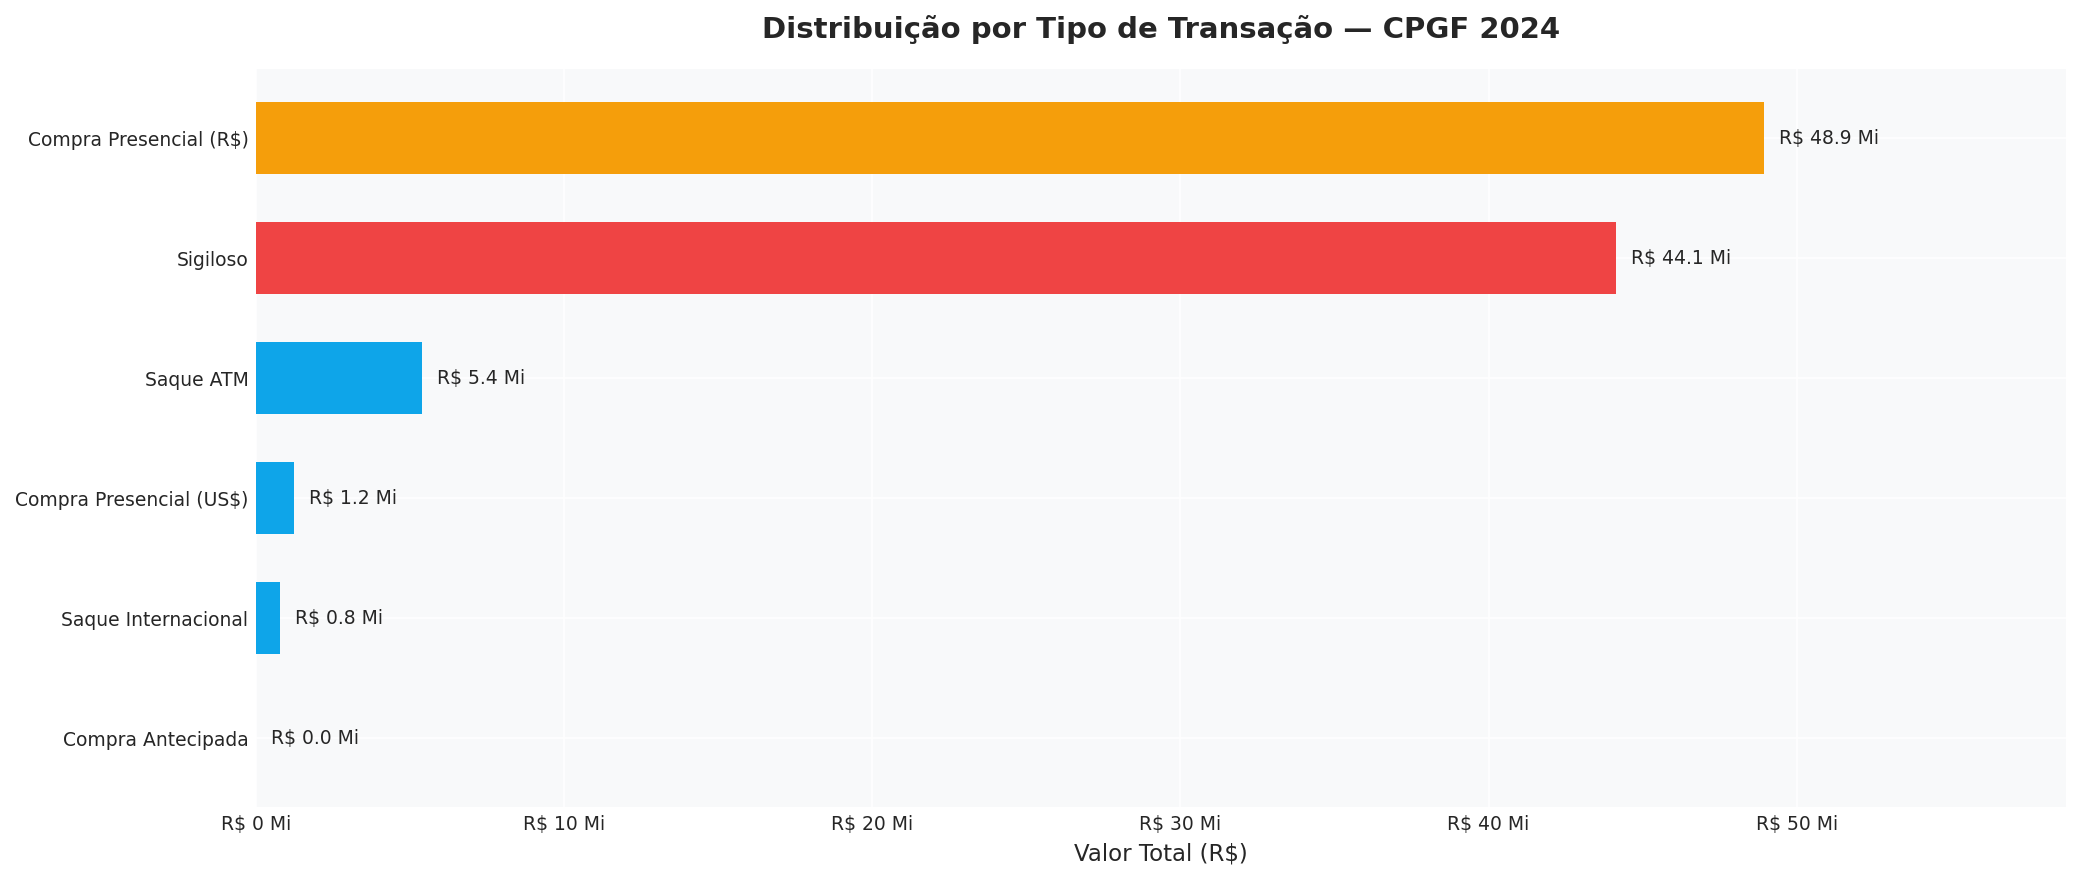

In [11]:
"""
Análise da distribuição de gastos por tipo de transação CPGF 2024.

Processo:
1. Agrupa gastos por tipo de transação e soma os valores
2. Ordena em ordem crescente (menor → maior)
3. Aplica cores diferenciadas por categoria
4. Inclui todos os tipos, inclusive registros sigilosos

Insight:
- Registros sigilosos representam uma parcela significativa
  das transações, relevante numa análise de transparência governamental.

Resultado: Gráfico de barras horizontal mostrando a distribuição
de gastos por tipo de transação.
"""

# Agrupa por tipo de transação
gastos_transacao = (df.groupby('transacao')['valor_transacao']
                      .sum()
                      .sort_values(ascending=True))

# Simplifica nomes para visualização
nomes_transacao = {
    'COMPRA A/V - R$ - APRES'             : 'Compra Presencial (R$)',
    'Informações protegidas por sigilo'    : 'Sigiloso',
    'SAQUE CASH/ATM BB'                   : 'Saque ATM',
    'COMPRA A/V - INT$ - APRES'           : 'Compra Presencial (US$)',
    'SAQUE - INT$ - APRES'               : 'Saque Internacional',
    'COMP A/V-SOL DISP C/CLI-R$ ANT VENC': 'Compra Antecipada',
}
gastos_transacao.index = gastos_transacao.index.map(
    lambda x: nomes_transacao.get(x, x))

# Cores — destaca sigiloso em vermelho, maior em amarelo, demais em azul
cores = []
for nome in gastos_transacao.index:
    if nome == 'Sigiloso':
        cores.append('#EF4444')
    elif nome == gastos_transacao.index[-1]:
        cores.append('#F59E0B')
    else:
        cores.append('#0EA5E9')

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(gastos_transacao.index, gastos_transacao.values,
               color=cores, height=0.6)

# Rótulos de valor
for bar, val in zip(bars, gastos_transacao.values):
    ax.text(val + gastos_transacao.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'R$ {val/1e6:.1f} Mi',
            va='center', ha='left', fontsize=9)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'R$ {x/1e6:.0f} Mi'))

ax.set_xlim(0, gastos_transacao.max() * 1.2)
ax.set_title('Distribuição por Tipo de Transação — CPGF 2024', pad=15)
ax.set_xlabel('Valor Total (R$)')

plt.tight_layout()
plt.savefig('grafico_2_transacao.png')
plt.show()

In [12]:
# ANÁLISE DO GRÁFICO
transacao_orgaos = (df.groupby('transacao')['valor_transacao'].sum().sort_values(ascending=False))

total = transacao_orgaos.sum()
sigiloso = transacao_orgaos.get('Informações protegidas por sigilo', 0)
pct_sigiloso = (sigiloso / total) * 100

print("=" * 60)
print("ANÁLISE: DISTRIBUIÇÃO POR TIPO DE TRANSAÇÃO CPGF 2024")
print("=" * 60)

print(f"\nRANKING DOS TIPOS DE TRANSAÇÃO:")
for i, (tipo, valor) in enumerate(transacao_orgaos.items(), 1):
    pct = (valor / total) * 100
    print(f"{i:2d}. {tipo:40s} R$ {valor:>12,.2f} ({pct:5.1f}%)")

print(f"\nESTATÍSTICAS:")
print(f"Total: R$ {total:,.2f}")
print(f"Média: R$ {transacao_orgaos.mean():,.2f}")

print(f"\nINSIGHT PRINCIPAL:")
print(f" - R$ {sigiloso:,.2f} ({pct_sigiloso:.1f}%) das transações são sigilosas.")
print(f" - Valor equivalente às compras presenciais e levanta")
print(f"   questionamentos sobre transparência dos gastos públicos.")

ANÁLISE: DISTRIBUIÇÃO POR TIPO DE TRANSAÇÃO CPGF 2024

RANKING DOS TIPOS DE TRANSAÇÃO:
 1. COMPRA A/V - R$ - APRES                  R$ 48,933,324.02 ( 48.7%)
 2. Informações protegidas por sigilo        R$ 44,134,905.59 ( 43.9%)
 3. SAQUE CASH/ATM BB                        R$ 5,385,852.00 (  5.4%)
 4. COMPRA A/V - INT$ - APRES                R$ 1,245,605.46 (  1.2%)
 5. SAQUE - INT$ - APRES                     R$   787,851.12 (  0.8%)
 6. COMP A/V-SOL DISP C/CLI-R$ ANT VENC      R$     1,300.00 (  0.0%)

ESTATÍSTICAS:
Total: R$ 100,488,838.19
Média: R$ 16,748,139.70

INSIGHT PRINCIPAL:
 - R$ 44,134,905.59 (43.9%) das transações são sigilosas.
 - Valor equivalente às compras presenciais e levanta
   questionamentos sobre transparência dos gastos públicos.


#### 3 - Sazonalidade Mensal

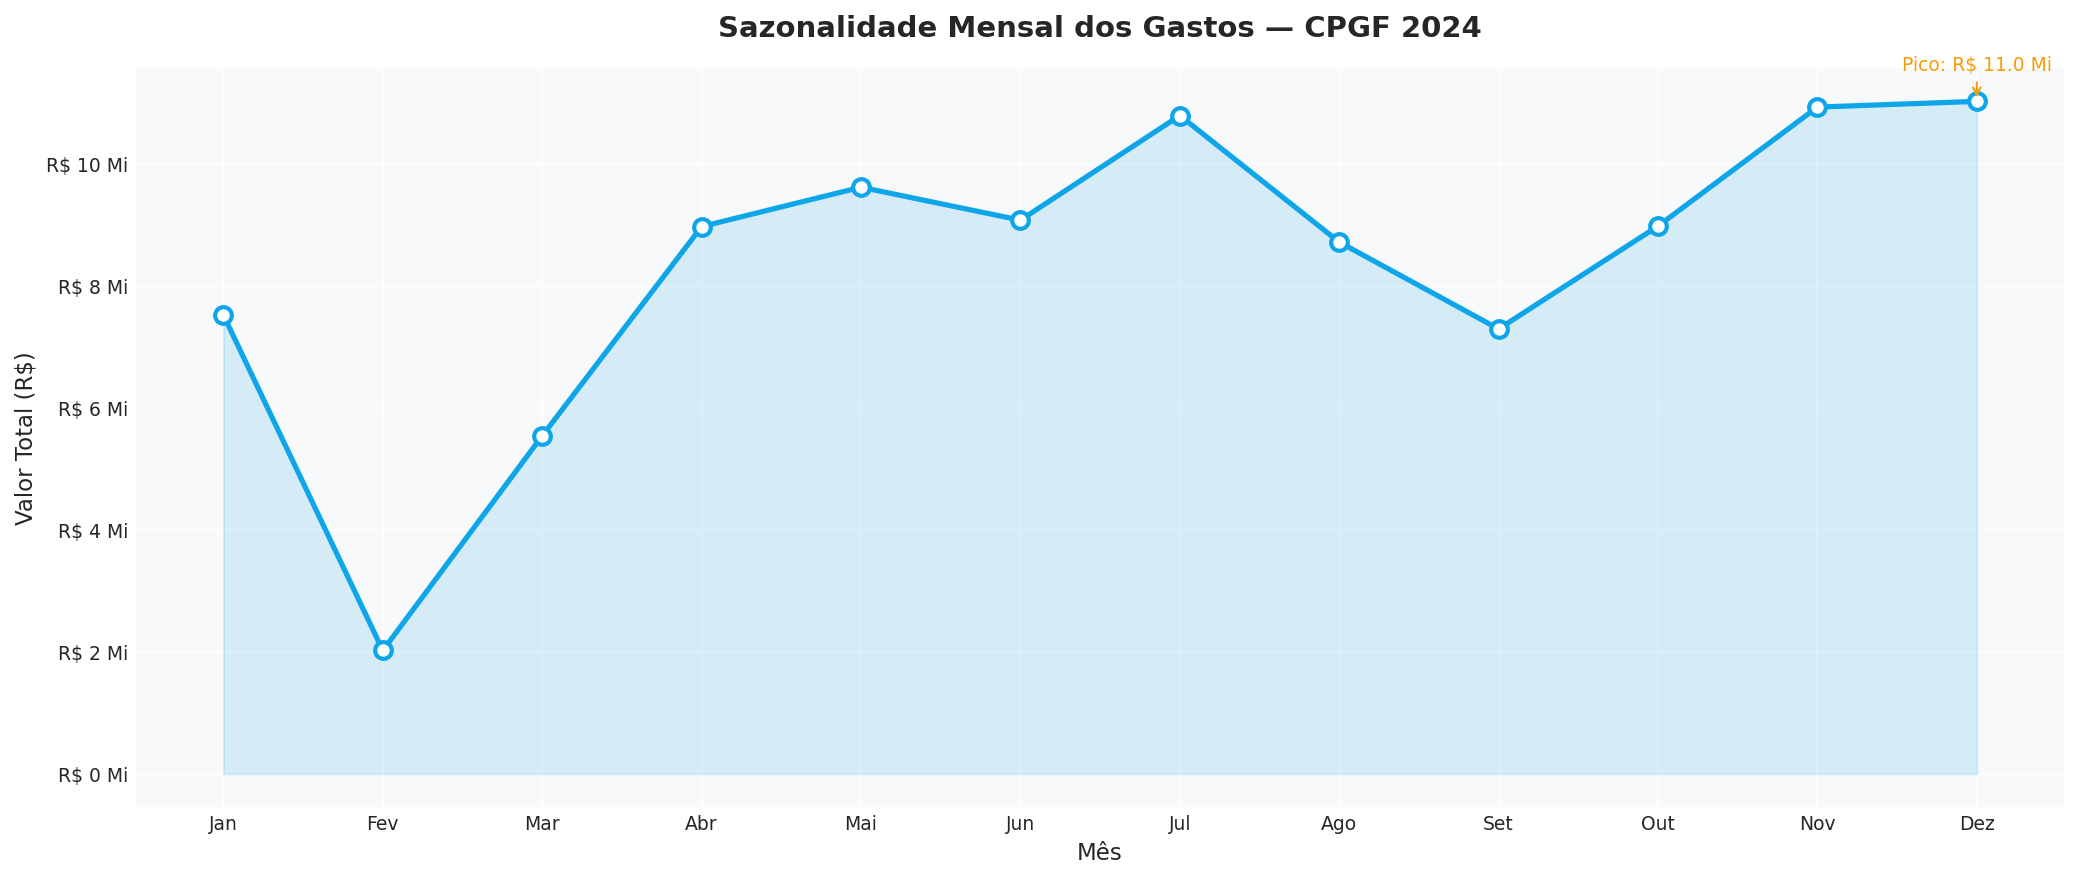

In [13]:
"""
Análise de sazonalidade mensal dos gastos CPGF 2024.

Processo:
1. Agrupa gastos por mês e soma os valores
2. Mapeia números para nomes dos meses em português
3. Plota linha com área preenchida
4. Destaca o mês de maior gasto com anotação

Resultado: Gráfico de linha mostrando a tendência
de gastos ao longo dos 12 meses de 2024.
"""

meses_pt = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
            7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}

sazonalidade = (df.groupby('mes_extrato')['valor_transacao']
                  .sum()
                  .sort_index())

sazonalidade.index = sazonalidade.index.map(meses_pt)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(range(len(sazonalidade)), sazonalidade.values,
                alpha=0.15, color='#0EA5E9')

ax.plot(range(len(sazonalidade)), sazonalidade.values,
        color='#0EA5E9', linewidth=2.5,
        marker='o', markersize=8,
        markerfacecolor='white',
        markeredgecolor='#0EA5E9',
        markeredgewidth=2)

# Destaca o pico
pico_idx = sazonalidade.values.argmax()
pico_val = sazonalidade.values[pico_idx]
ax.annotate(f'Pico: R$ {pico_val/1e6:.1f} Mi',
            xy=(pico_idx, pico_val),
            xytext=(0, 15), textcoords='offset points',
            ha='center', fontsize=9, color='#F59E0B',
            arrowprops=dict(arrowstyle='->', color='#F59E0B'))

ax.set_xticks(range(len(sazonalidade)))
ax.set_xticklabels(sazonalidade.index, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'R$ {x/1e6:.0f} Mi'))

ax.set_title('Sazonalidade Mensal dos Gastos — CPGF 2024', pad=15)
ax.set_xlabel('Mês')
ax.set_ylabel('Valor Total (R$)')

plt.tight_layout()
plt.savefig('grafico_3_sazonalidade.png')
plt.show()

In [18]:
# ANÁLISE DO GRÁFICO 
sazonalidade_analise = (df.groupby('mes_extrato')['valor_transacao'].sum().sort_index())

meses_pt = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
            7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}

total = sazonalidade_analise.sum()
pico_mes = sazonalidade_analise.idxmax()
vale_mes = sazonalidade_analise.idxmin()

print("=" * 60)
print("ANÁLISE: SAZONALIDADE MENSAL DOS GASTOS CPGF 2024")
print("=" * 60)

print(f"\nGASTOS MENSAIS:")
for mes, valor in sazonalidade_analise.items():
    pct = (valor / total) * 100
    print(f"{meses_pt[mes]:3s}: R$ {valor:>12,.2f} ({pct:5.2f}%)")

print(f"\nESTATÍSTICAS:")
print(f"Total anual: R$ {total:,.2f}")
print(f"Média mensal: R$ {sazonalidade_analise.mean():,.2f}")
print(f"Maior gasto: {meses_pt[pico_mes]} — R$ {sazonalidade_analise.max():,.2f}")
print(f"Menor gasto: {meses_pt[vale_mes]} — R$ {sazonalidade_analise.min():,.2f}")

print(f"\nINSIGHT PRINCIPAL:")

variacao = ((sazonalidade_analise.max() - sazonalidade_analise.min()) / sazonalidade_analise.mean()) * 100

print(f" - Fevereiro apresenta queda maior em relação aos outros meses")
print(f"   pelo reflexo do menor número de dias úteis no mês")
print(f" - Tendência de alta no 2 semestre, com pico em Dezembro")
print(f"   sugerindo aceleração de gastos no fechamento do ano.")
print(f" - Variação entre pico e vale: {variacao:.1f}%")

ANÁLISE: SAZONALIDADE MENSAL DOS GASTOS CPGF 2024

GASTOS MENSAIS:
Jan: R$ 7,521,793.10 ( 7.49%)
Fev: R$ 2,022,103.01 ( 2.01%)
Mar: R$ 5,540,764.64 ( 5.51%)
Abr: R$ 8,971,366.81 ( 8.93%)
Mai: R$ 9,617,184.02 ( 9.57%)
Jun: R$ 9,077,091.04 ( 9.03%)
Jul: R$ 10,792,190.36 (10.74%)
Ago: R$ 8,717,808.03 ( 8.68%)
Set: R$ 7,293,306.40 ( 7.26%)
Out: R$ 8,979,295.05 ( 8.94%)
Nov: R$ 10,931,003.80 (10.88%)
Dez: R$ 11,024,931.93 (10.97%)

ESTATÍSTICAS:
Total anual: R$ 100,488,838.19
Média mensal: R$ 8,374,069.85
Maior gasto: Dez — R$ 11,024,931.93
Menor gasto: Fev — R$ 2,022,103.01

INSIGHT PRINCIPAL:
 - Fevereiro apresenta queda maior em relação aos outros meses
   pelo reflexo do menor número de dias úteis no mês
 - Tendência de alta no 2 semestre, com pico em Dezembro
   sugerindo aceleração de gastos no fechamento do ano.
 - Variação entre pico e vale: 107.5%


#### 4 - Top portadores

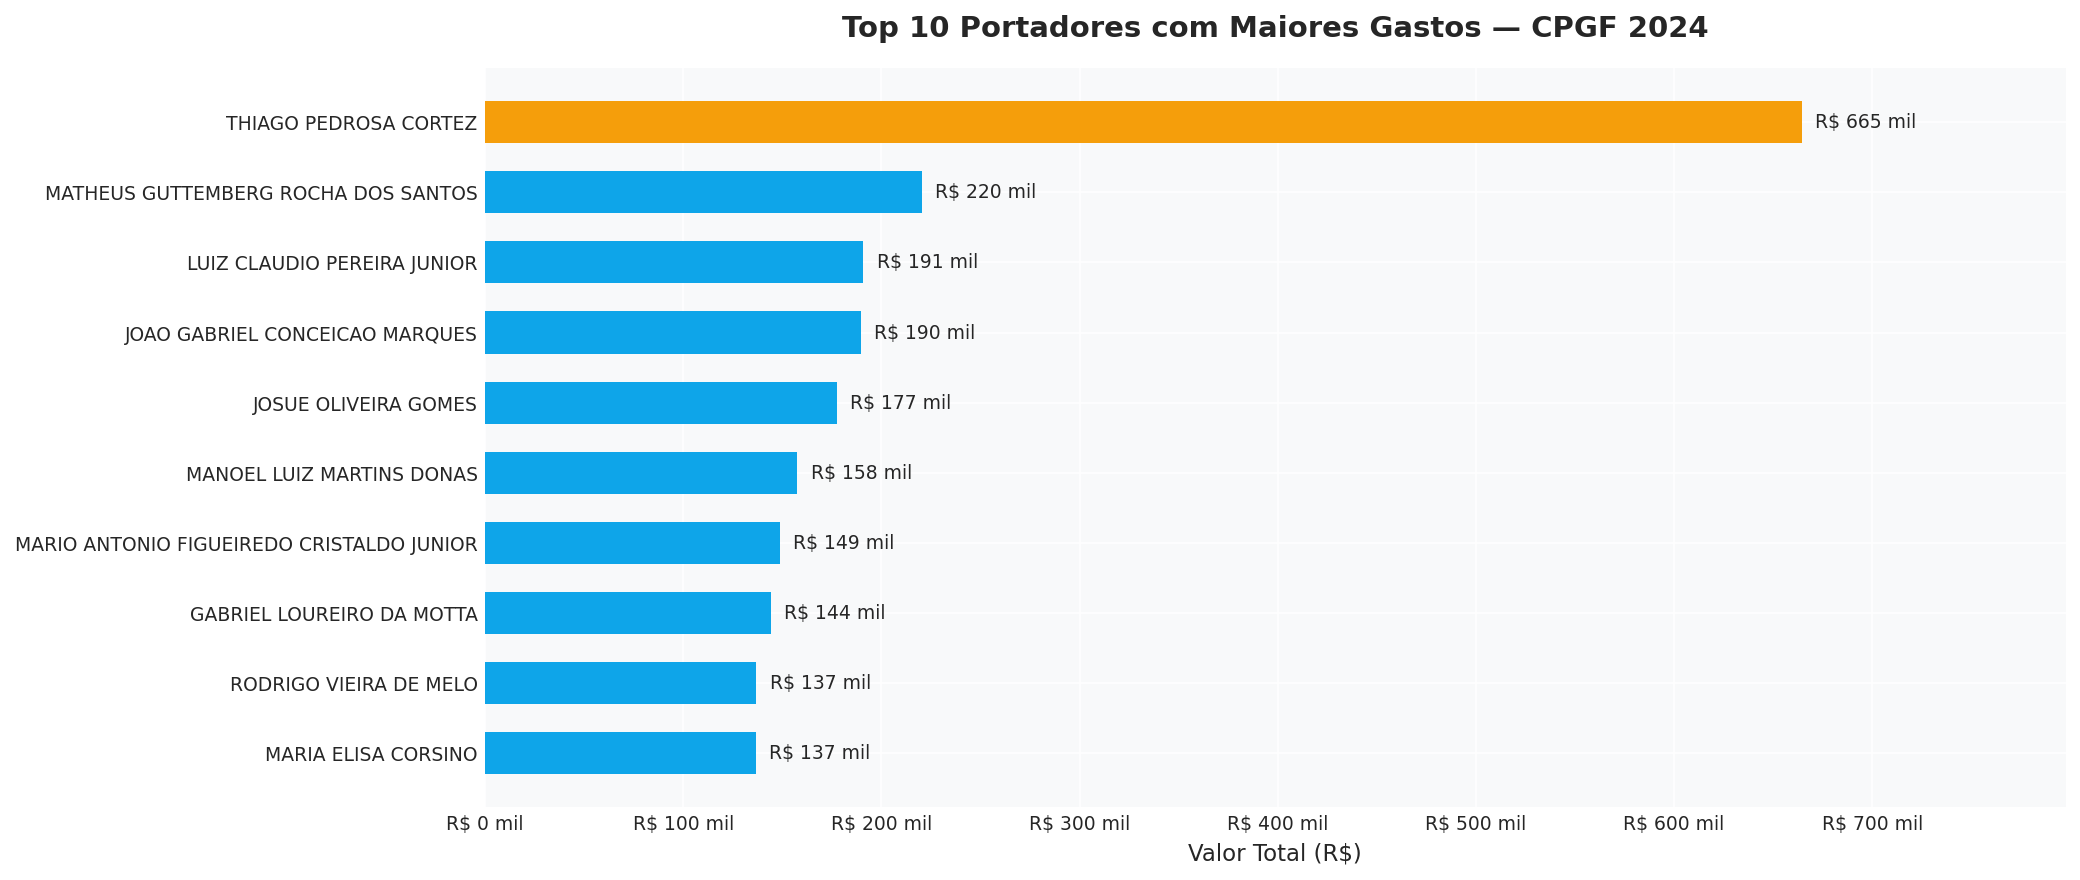

In [ ]:
"""
Análise dos Top 10 portadores com maiores gastos CPGF 2024.

Processo:
1. Remover os registros sigilosos (sem identificação pública)
2. Agrupar gastos por nome do portador e somar os valores
3. Selecionar os top 10 em ordem crescente (menor para maior)
4. Destacar o maior portador com uma cor destacada

OBS: 36.472 registros sigilosos foram excluídos desta análise
por falta de identificação do portador.

Resultado: Gráfico de barras horizontal mostrando os servidores
que mais utilizaram o CPGF em 2024.
"""

# Remove sigilosos e agrupa
gastos_portador = (df[df['nome_portador'] != 'Sigiloso'].groupby('nome_portador')['valor_transacao'].sum().nlargest(10).sort_values(ascending=True))

# Cores
n = len(gastos_portador)
cores = ['#0EA5E9'] * n
cores[-1] = '#F59E0B'

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(gastos_portador.index, gastos_portador.values,color=cores, height=0.6)

# Rótulos de valor
for bar, val in zip(bars, gastos_portador.values):
    ax.text(val + gastos_portador.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'R$ {val/1e3:.0f} mil',
            va='center', ha='left', fontsize=9)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e3:.0f} mil'))

ax.set_xlim(0, gastos_portador.max() * 1.2)
ax.set_title('Top 10 Portadores com Maiores Gastos — CPGF 2024', pad=15)
ax.set_xlabel('Valor Total (R$)')

plt.tight_layout()
plt.savefig('grafico_4_portadores.png')
plt.show()

In [22]:
# ANÁLISE DO GRÁFICO 
gastos_portador_analise = (df[df['nome_portador'] != 'Sigiloso'].groupby('nome_portador')['valor_transacao'].sum().nlargest(10).sort_values(ascending=False))

total_geral = df['valor_transacao'].sum()
total_top10 = gastos_portador_analise.sum()
pct_top10 = (total_top10 / total_geral) * 100

maior_portador = gastos_portador_analise.index[0]
maior_valor = gastos_portador_analise.iloc[0]
segundo_valor = gastos_portador_analise.iloc[1]
proporcao = maior_valor / segundo_valor

print("=" * 60)
print("ANÁLISE: TOP 10 PORTADORES COM MAIORES GASTOS CPGF 2024")
print("=" * 60)

print("\nRANKING DOS TOP 10 PORTADORES:")
for i, (portador, valor) in enumerate(gastos_portador_analise.items(), 1):
    pct = (valor / total_geral) * 100
    print(f"{i:2d}. {portador:40s} R$ {valor:>10,.2f} ({pct:5.1f}%)")

print(f"\nESTATÍSTICAS:")
print(f"Total: R$ {total_top10:,.2f}")
print(f"Média: R$ {gastos_portador_analise.mean():,.2f}")
print(f"Maior: R$ {maior_valor:,.2f}")
print(f"Menor: R$ {gastos_portador_analise.iloc[-1]:,.2f}")

print("\nINSIGHT PRINCIPAL:")
print(f" - {maior_portador} é o portador com maior gasto,")
print(f"   {proporcao:.1f}x acima do segundo colocado — concentração atípica.")
print(f" - Top 10 portadores representam {pct_top10:.1f}% do total geral.")
print(f" - 36.472 registros sigilosos foram excluídos desta análise")

ANÁLISE: TOP 10 PORTADORES COM MAIORES GASTOS CPGF 2024

RANKING DOS TOP 10 PORTADORES:
 1. THIAGO PEDROSA CORTEZ                    R$ 664,590.25 (  0.7%)
 2. MATHEUS GUTTEMBERG ROCHA DOS SANTOS      R$ 220,500.00 (  0.2%)
 3. LUIZ CLAUDIO PEREIRA JUNIOR              R$ 190,963.24 (  0.2%)
 4. JOAO GABRIEL CONCEICAO MARQUES           R$ 189,650.00 (  0.2%)
 5. JOSUE OLIVEIRA GOMES                     R$ 177,490.98 (  0.2%)
 6. MANOEL LUIZ MARTINS DONAS                R$ 157,600.54 (  0.2%)
 7. MARIO ANTONIO FIGUEIREDO CRISTALDO JUNIOR R$ 148,604.73 (  0.1%)
 8. GABRIEL LOUREIRO DA MOTTA                R$ 144,191.29 (  0.1%)
 9. RODRIGO VIEIRA DE MELO                   R$ 136,946.39 (  0.1%)
10. MARIA ELISA CORSINO                      R$ 136,581.33 (  0.1%)

ESTATÍSTICAS:
Total: R$ 2,167,118.75
Média: R$ 216,711.88
Maior: R$ 664,590.25
Menor: R$ 136,581.33

INSIGHT PRINCIPAL:
 - THIAGO PEDROSA CORTEZ é o portador com maior gasto,
   3.0x acima do segundo colocado — concentração atípic

#### 5 - Top Favorecidos

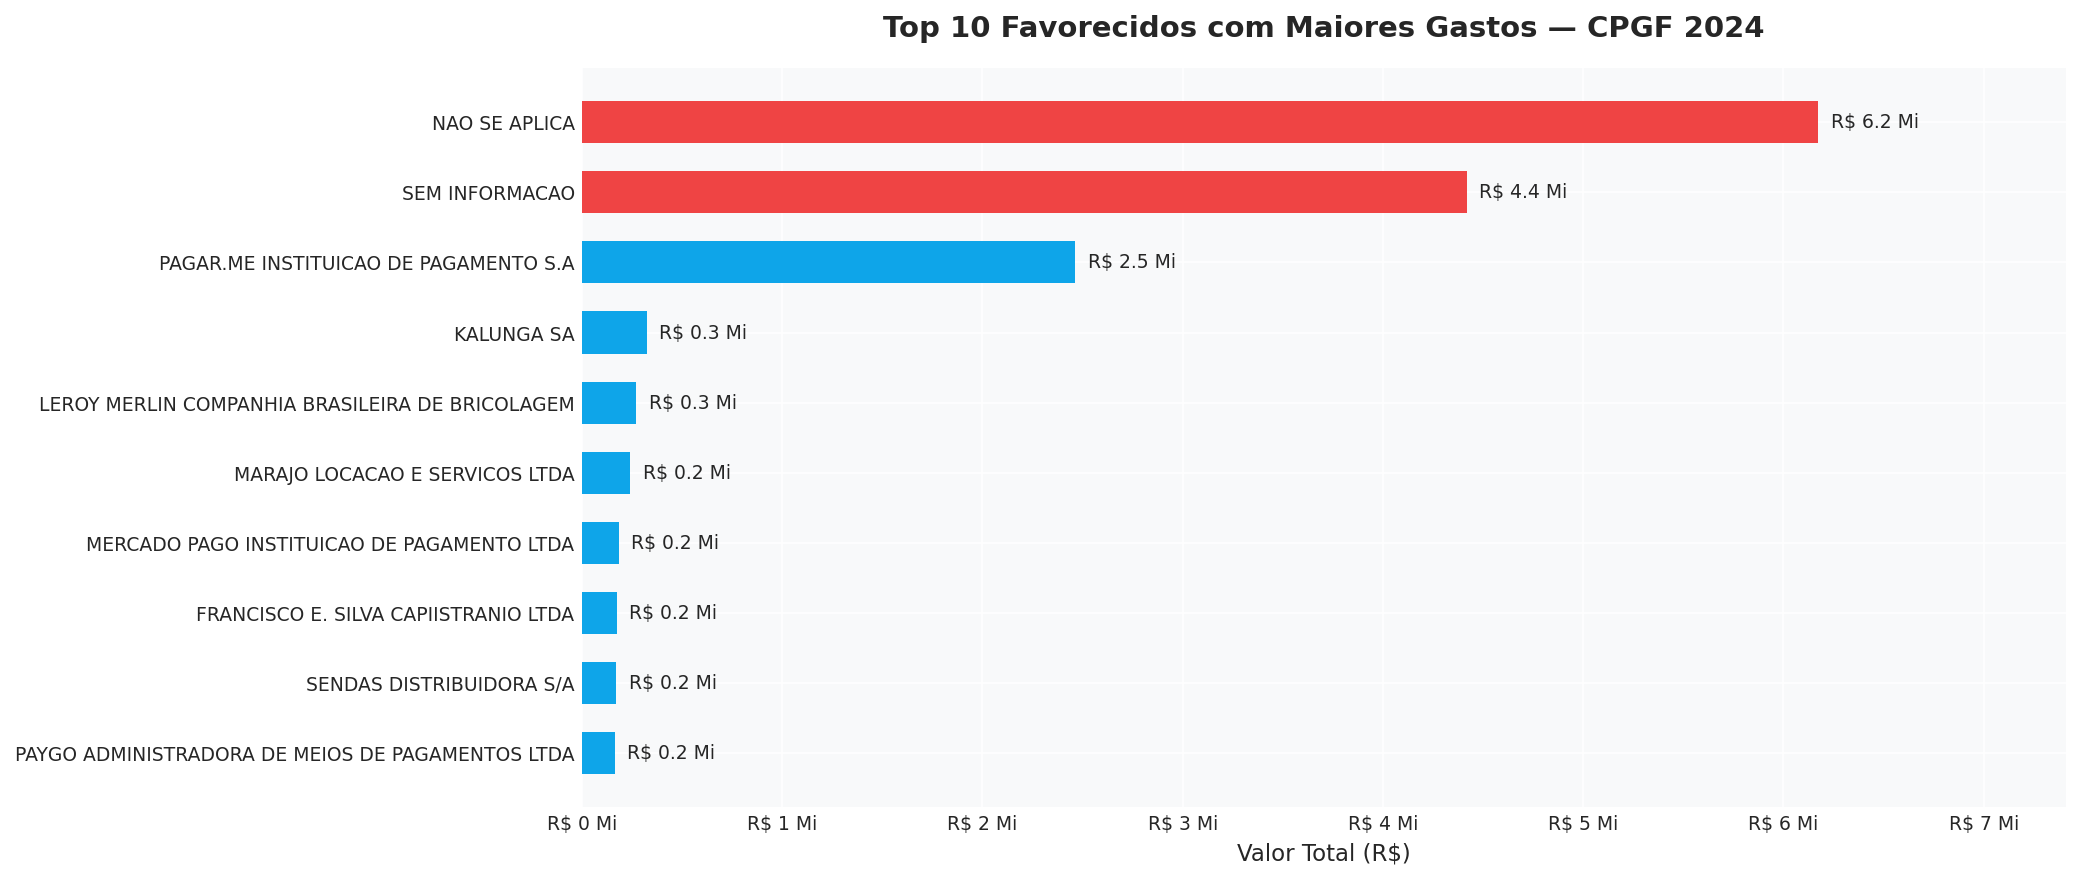

In [ ]:
"""
Análise dos Top 10 favorecidos com maiores gastos CPGF 2024.

Processo:
1. Remover os registros sigilosos (sem identificação pública)
2. Mantive o 'NAO SE APLICA' e 'SEM INFORMACAO' como categorias válidas
3. Agrupei os gastos por favorecido e soma pelos valores
4. Selecionei os top 10 em ordem crescente (menor para maior)
5. Destaquei o maior favorecido com cor de destaque.

OBS: 36.472 registros sigilosos foram excluídos desta análise.
'NAO SE APLICA' e 'SEM INFORMACAO' foram mantidos pois
representam ausência de dado no sistema a uma informação relevante.

Resultado: Um gráfico de barras horizontal mostrando os favorecidos
que mais receberam recursos via CPGF em 2024.
"""

# Remove sigilosos e agrupa
gastos_favorecido = (df[df['nome_favorecido'] != 'Sigiloso'].groupby('nome_favorecido')['valor_transacao'].sum().nlargest(10).sort_values(ascending=True))

# Cores — destaca NAO SE APLICA e SEM INFORMACAO em vermelho
cores = []
for nome in gastos_favorecido.index:
    if nome in ['NAO SE APLICA', 'SEM INFORMACAO']:
        cores.append('#EF4444')
    elif nome == gastos_favorecido.index[-1]:
        cores.append('#F59E0B')
    else:
        cores.append('#0EA5E9')

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(gastos_favorecido.index, gastos_favorecido.values,color=cores, height=0.6)

# Rótulos de valor
for bar, val in zip(bars, gastos_favorecido.values):
    ax.text(val + gastos_favorecido.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'R$ {val/1e6:.1f} Mi',
            va='center', ha='left', fontsize=9)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.0f} Mi'))

ax.set_xlim(0, gastos_favorecido.max() * 1.2)
ax.set_title('Top 10 Favorecidos com Maiores Gastos — CPGF 2024', pad=15)
ax.set_xlabel('Valor Total (R$)')

plt.tight_layout()
plt.savefig('grafico_5_favorecidos.png')
plt.show()

In [29]:
# ANÁLISE DO GRÁFICO 5
gastos_favorecido_analise = (df[df['nome_favorecido'] != 'Sigiloso'].groupby('nome_favorecido')['valor_transacao'].sum().nlargest(10).sort_values(ascending=False))

total_geral = df['valor_transacao'].sum()
total_top10 = gastos_favorecido_analise.sum()
pct_top10 = (total_top10 / total_geral) * 100

nao_identificado = (gastos_favorecido_analise.get('NAO SE APLICA', 0) + gastos_favorecido_analise.get('SEM INFORMACAO', 0))
pct_nao_identificado = (nao_identificado / total_geral) * 100

print("=" * 60)
print("ANÁLISE: TOP 10 FAVORECIDOS COM MAIORES GASTOS CPGF 2024")
print("=" * 60)

print("\nRANKING DOS TOP 10 FAVORECIDOS:")
for i, (favorecido, valor) in enumerate(gastos_favorecido_analise.items(), 1):
    pct = (valor / total_geral) * 100
    print(f"{i:2d}. {favorecido:45s} R$ {valor:>12,.2f} ({pct:5.2f}%)")

print(f"\nESTATÍSTICAS:")
print(f"Total: R$ {total_top10:,.2f}")
print(f"Média: R$ {gastos_favorecido_analise.mean():,.2f}")
print(f"Maior: R$ {gastos_favorecido_analise.iloc[0]:,.2f}")
print(f"Menor: R$ {gastos_favorecido_analise.iloc[-1]:,.2f}")

print("\nINSIGHT PRINCIPAL:")
print(f" - R$ {nao_identificado:,.2f} ({pct_nao_identificado:.1f}%) sem o favorecido identificado")
print(f"   somando 'NAO SE APLICA' + 'SEM INFORMACAO'.")
print(f" - O valor supera qualquer empresa identificada no ranking")
print(f"   o que levanta questões sobre a rastreabilidade dos gastos públicos.")
print(f" - 36.472 registros sigilosos foram excluídos desta análise")

ANÁLISE: TOP 10 FAVORECIDOS COM MAIORES GASTOS CPGF 2024

RANKING DOS TOP 10 FAVORECIDOS:
 1. NAO SE APLICA                                 R$ 6,173,703.12 ( 6.14%)
 2. SEM INFORMACAO                                R$ 4,417,388.29 ( 4.40%)
 3. PAGAR.ME INSTITUICAO DE PAGAMENTO S.A         R$ 2,464,622.45 ( 2.45%)
 4. KALUNGA SA                                    R$   322,789.93 ( 0.32%)
 5. LEROY MERLIN COMPANHIA BRASILEIRA DE BRICOLAGEM R$   271,540.72 ( 0.27%)
 6. MARAJO LOCACAO E SERVICOS LTDA                R$   242,150.00 ( 0.24%)
 7. MERCADO PAGO INSTITUICAO DE PAGAMENTO LTDA    R$   183,350.35 ( 0.18%)
 8. FRANCISCO E. SILVA CAPIISTRANIO LTDA          R$   173,700.00 ( 0.17%)
 9. SENDAS DISTRIBUIDORA S/A                      R$   171,941.69 ( 0.17%)
10. PAYGO ADMINISTRADORA DE MEIOS DE PAGAMENTOS LTDA R$   165,169.90 ( 0.16%)

ESTATÍSTICAS:
Total: R$ 14,586,356.45
Média: R$ 1,458,635.65
Maior: R$ 6,173,703.12
Menor: R$ 165,169.90

INSIGHT PRINCIPAL:
 - R$ 10,591,091.41 (10.5%) s

#### 6 - Ticket Médio por Órgão!

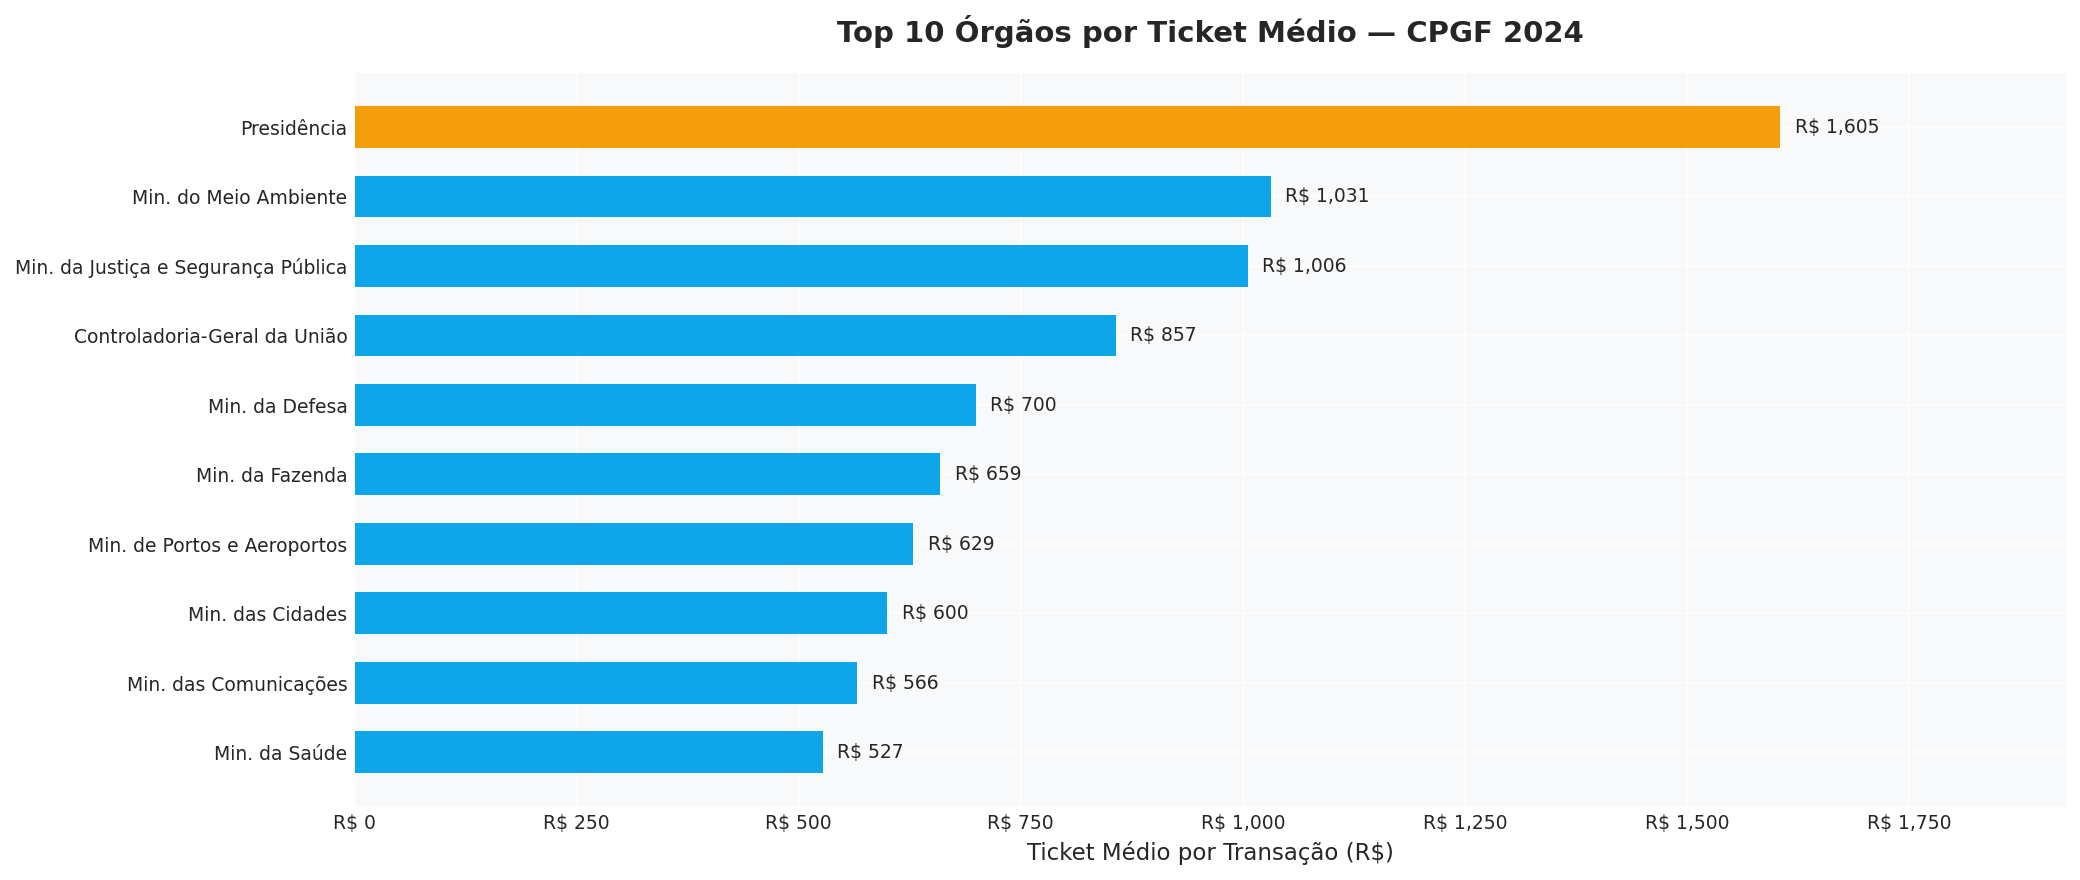

In [30]:
"""
Análise do ticket médio por órgão superior CPGF 2024.

Ticket Médio = Valor total do órgão = Quantidade de transações

Processo:
1. Agrupar as transações por órgão superior
2. Calcular, somar e realizar a contagem por órgão
3. Filtrar os órgãos com menos de 50 transações para evitar distorção
4. Calcular o ticket médio = soma / contagem
5. Seleciona os top 10 em ordem crescente (menor para maior)
6. Simplificar e corrigir os nomes dos órgãos

Exemplo:
- Ticket alto = órgão faz compras maiores/concentradas
- Ticket baixo = órgão faz muitas pequenas transações

Resultado: Um gráfico de barras horizontal mostrando os órgãos
com maior valor médio por transação em 2024.
"""

# Agrupa e calcula ticket médio
ticket = (df.groupby('nome_orgao_superior')['valor_transacao'].agg(['sum', 'count']))

# Filtra órgãos com mínimo de 50 transações
ticket = ticket[ticket['count'] >= 50]

# Calcula ticket médio
ticket['media'] = ticket['sum'] / ticket['count']

# Seleciona top 10
ticket_top10 = (ticket['media'].nlargest(10).sort_values(ascending=True))

# Simplifica nomes
ticket_top10.index = (ticket_top10.index
                      .str.replace('Ministério', 'Min.')
                      .str.replace(' da República', '')
                      .str.replace(' do Brasil', '')
                      .str.replace(' Federal', '')
                      .str.split(' - ').str[0]
                      .str.strip()
                      .str.replace('Min. do Meio Ambiente e Mudança do Cl', 'Min. do Meio Ambiente')
                      .str.replace('Min. do Desenvolvimento Agrário e Agr', 'Min. do Desenv. Agrário'))

# Cores
n = len(ticket_top10)
cores = ['#0EA5E9'] * n
cores[-1] = '#F59E0B'

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(ticket_top10.index, ticket_top10.values,color=cores, height=0.6)

# Rótulos de valor
for bar, val in zip(bars, ticket_top10.values):
    ax.text(val + ticket_top10.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'R$ {val:,.0f}',
            va='center', ha='left', fontsize=9)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

ax.set_xlim(0, ticket_top10.max() * 1.2)
ax.set_title('Top 10 Órgãos por Ticket Médio — CPGF 2024', pad=15)
ax.set_xlabel('Ticket Médio por Transação (R$)')

plt.tight_layout()
plt.savefig('grafico_6_ticket_medio.png')
plt.show()

In [ ]:
# ANÁLISE DO GRÁFICO 
ticket_analise = (df.groupby('nome_orgao_superior')['valor_transacao'].agg(['sum', 'count']))

ticket_analise = ticket_analise[ticket_analise['count'] >= 50]
ticket_analise['media'] = ticket_analise['sum'] / ticket_analise['count']

ticket_top10_analise = (ticket_analise['media'].nlargest(10).sort_values(ascending=False))

media_geral = df['valor_transacao'].mean()
maior_orgao = ticket_top10_analise.index[0]
maior_ticket = ticket_top10_analise.iloc[0]
segundo_ticket = ticket_top10_analise.iloc[1]
proporcao = maior_ticket / segundo_ticket

print("=" * 60)
print("ANÁLISE: TICKET MÉDIO POR ÓRGÃO CPGF 2024")
print("=" * 60)

print("\nRANKING DO TICKET MÉDIO (TOP 10):")
print("(Ticket Médio = Valor total / Quantidade de transações)\n")
for i, (orgao, valor) in enumerate(ticket_top10_analise.items(), 1):
    print(f"{i:2d}. {orgao:45s} R$ {valor:>10,.2f}")

print(f"\nESTATÍSTICAS:")
print(f" - Ticket Médio Geral: R$ {media_geral:,.2f}")
print(f" - Maior Ticket: R$ {maior_ticket:,.2f} ({maior_orgao})")
print(f" - Menor Ticket: R$ {ticket_top10_analise.iloc[-1]:,.2f}")
print(f" - Desvio Padrão: R$ {ticket_top10_analise.std():,.2f}")

print("\nINSIGHT PRINCIPAL:")
print(f" - Presidência tem ticket médio de R$ {maior_ticket:,.2f},")
print(f"   {proporcao:.1f}x acima do segundo colocado a transações")
print(f"   mais concentradas e de maior valor individual.")
print(f" - Ticket médio geral de R$ {media_geral:,.2f} indica que")
print(f"   a maioria dos órgãos opera com transações menores.")
print(f" - Filtro aplicado: apenas órgãos com 50+ transações")

ANÁLISE: TICKET MÉDIO POR ÓRGÃO CPGF 2024

RANKING DO TICKET MÉDIO (TOP 10):
(Ticket Médio = Valor total / Quantidade de transações)

 1. Presidência da República                      R$   1,605.23
 2. Ministério do Meio Ambiente e Mudança do Cl   R$   1,031.17
 3. Ministério da Justiça e Segurança Pública     R$   1,005.67
 4. Controladoria-Geral da União                  R$     856.98
 5. Ministério da Defesa                          R$     699.77
 6. Ministério da Fazenda                         R$     659.36
 7. Ministério de Portos e Aeroportos             R$     629.11
 8. Ministério das Cidades                        R$     599.92
 9. Ministério das Comunicações                   R$     566.06
10. Ministério da Saúde                           R$     527.41

ESTATÍSTICAS:
 - Ticket Médio Geral: R$ 712.44
 - Maior Ticket: R$ 1,605.23 (Presidência da República)
 - Menor Ticket: R$ 527.41
 - Desvio Padrão: R$ 328.67

INSIGHT PRINCIPAL:
 - Presidência tem ticket médio de R$ 1,605.23,

## Exportando Resultados:

In [ ]:
df.to_csv(r'C:\Users\User\Desktop\Projeto_GOV_DATA\Resultados_Analise\CPGF_2024_Processado.csv', index=False, encoding='utf-8-sig')

print("Arquivo exportado com sucesso!")
print(f"Registros exportados: {len(df):,}")
print(f"Colunas: {len(df.columns)}")
print(f"Caminho: Resultados_Analise/CPGF_2024_Processado.csv")

Arquivo exportado com sucesso!
Registros exportados: 141,048
Colunas: 15
Caminho: Resultados_Analise/CPGF_2024_Processado.csv
